In [1]:
!pip install -q pandas numpy scikit-learn matplotlib seaborn xgboost joblib pyarrow

In [12]:
!wget -q -O unsw-nb15.zip "https://www.kaggle.com/api/v1/datasets/download/strgenix/unsw-nb15"

print("Dataset downloaded successfully! ✅")

Dataset downloaded successfully! ✅


In [13]:
import os

if os.path.exists("unsw-nb15.zip"):
    os.remove("unsw-nb15.zip")

print("Old file removed. ✅")

Old file removed. ✅


In [14]:
import requests

url = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain%2B.txt"

response = requests.get(url)

print("Status:", response.status_code)
print("File size:", len(response.content))

Status: 200
File size: 19109424


In [15]:
from google.colab import files

uploaded = files.upload()

Saving kaggle.json to kaggle (1).json


In [16]:
import os

print(os.listdir("/content"))

['.config', 'kaggle (1).json', 'kaggle.json', 'unsw_dataset', 'sample_data']


In [17]:
!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API configured successfully! ✅")

Kaggle API configured successfully! ✅


In [18]:
!kaggle datasets list -s "UNSW-NB15"

ref                                                            title                                                   size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-------------------------------------------------------------  ------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
dhoogla/unswnb15                                               UNSW-NB15                                           12286680  2024-09-09 09:28:06.997000          19719        111                1  
dhoogla/nfunswnb15v2                                           NF-UNSW-NB15-V2                                     49538453  2023-01-13 20:36:09.737000          63390         13                1  
sankurisrinath/nf-unsw-nb15-v2csv                              NF-UNSW-NB15-V2.CSV                                 37060516  2023-06-22 05:28:02.280000           1545         31                1  
mrwellsdavid/un

In [20]:
!mkdir -p /content/unsw_download

!kaggle datasets download -d dhoogla/unswnb15 \
    -p /content/unsw_download

print("Download completed!")

Dataset URL: https://www.kaggle.com/datasets/dhoogla/unswnb15
License(s): CC-BY-NC-SA-4.0
unswnb15.zip: Skipping, found more recently modified local copy (use --force to force download)
Download completed!


In [21]:
!ls -lh /content/unsw_download

total 12M
-rw-r--r-- 1 root root 12M Sep  9  2024 unswnb15.zip


In [22]:
!mkdir -p /content/unsw_dataset

!unzip -o /content/unsw_download/*.zip \
    -d /content/unsw_dataset

print("Dataset extracted successfully!")

Archive:  /content/unsw_download/unswnb15.zip
  inflating: /content/unsw_dataset/UNSW_NB15_testing-set.parquet  
  inflating: /content/unsw_dataset/UNSW_NB15_training-set.parquet  
Dataset extracted successfully!


In [23]:
import os

for root, dirs, files in os.walk("/content/unsw_dataset"):
    for file in files:
        print(os.path.join(root, file))

/content/unsw_dataset/UNSW_NB15_training-set.parquet
/content/unsw_dataset/UNSW_NB15_testing-set.parquet


In [25]:
!pip install -q pandas numpy scikit-learn xgboost matplotlib seaborn joblib pyarrow

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from xgboost import XGBClassifier

print("Libraries imported successfully!")

Libraries imported successfully!


In [27]:
train_path = "/content/unsw_dataset/UNSW_NB15_training-set.parquet"
test_path = "/content/unsw_dataset/UNSW_NB15_testing-set.parquet"

train_df = pd.read_parquet(train_path)
test_df = pd.read_parquet(test_path)

print("Training shape:", train_df.shape)
print("Testing shape :", test_df.shape)

print("\nColumns:")
print(train_df.columns.tolist())

Training shape: (175341, 36)
Testing shape : (82332, 36)

Columns:
['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'is_sm_ips_ports', 'attack_cat', 'label']


In [28]:
print("Training columns:")
print(train_df.dtypes)

print("\nTarget distribution:")
print(train_df["label"].value_counts())

Training columns:
dur                   float32
proto                category
service              category
state                category
spkts                   int16
dpkts                   int16
sbytes                  int32
dbytes                  int32
rate                  float32
sload                 float32
dload                 float32
sloss                   int16
dloss                   int16
sinpkt                float32
dinpkt                float32
sjit                  float32
djit                  float32
swin                    int16
stcpb                   int64
dtcpb                   int64
dwin                    int16
tcprtt                float32
synack                float32
ackdat                float32
smean                   int16
dmean                   int16
trans_depth             int16
response_body_len       int32
ct_src_dport_ltm         int8
ct_dst_sport_ltm         int8
is_ftp_login             int8
ct_ftp_cmd               int8
ct_flw_http_mthd      

In [30]:
TARGET = "label"

X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]

X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]

# attack_cat is not needed for binary classification
if "attack_cat" in X_train.columns:
    X_train = X_train.drop(columns=["attack_cat"])
    X_test = X_test.drop(columns=["attack_cat"])

# ID is not useful for prediction
for col in ["id", "ID"]:
    if col in X_train.columns:
        X_train = X_train.drop(columns=[col])
        X_test = X_test.drop(columns=[col])

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (175341, 34)
X_test : (82332, 34)


In [31]:
encoders = {}

categorical_columns = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

for col in categorical_columns:
    encoder = LabelEncoder()

    combined = pd.concat([
        X_train[col].astype(str),
        X_test[col].astype(str)
    ])

    encoder.fit(combined)

    X_train[col] = encoder.transform(
        X_train[col].astype(str)
    )

    X_test[col] = encoder.transform(
        X_test[col].astype(str)
    )

    encoders[col] = encoder

print("\nCategorical encoding completed!")

Categorical columns:
['proto', 'service', 'state']

Categorical encoding completed!


In [32]:
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

print("Missing values in training:", X_train.isnull().sum().sum())
print("Missing values in testing :", X_test.isnull().sum().sum())

Missing values in training: 0
Missing values in testing : 0


In [33]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

print("Training XGBoost model...")

model.fit(
    X_train,
    y_train
)

print("Training completed! ✅")

Training XGBoost model...
Training completed! ✅


In [34]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Predictions completed!")

Predictions completed!


In [35]:
accuracy = accuracy_score(y_test, y_pred)

print("=" * 50)
print(f"MODEL ACCURACY: {accuracy * 100:.2f}%")
print("=" * 50)

MODEL ACCURACY: 87.01%


In [36]:
 print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Normal", "Attack"]
    )
)


Classification Report:
              precision    recall  f1-score   support

      Normal       0.96      0.74      0.84     37000
      Attack       0.82      0.98      0.89     45332

    accuracy                           0.87     82332
   macro avg       0.89      0.86      0.86     82332
weighted avg       0.88      0.87      0.87     82332



In [37]:
roc_auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC Score: {roc_auc:.4f}")

ROC-AUC Score: 0.9810


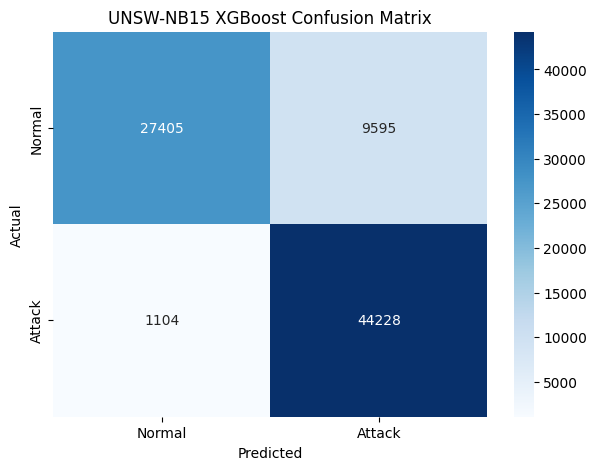

In [38]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Attack"],
    yticklabels=["Normal", "Attack"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("UNSW-NB15 XGBoost Confusion Matrix")

plt.show()

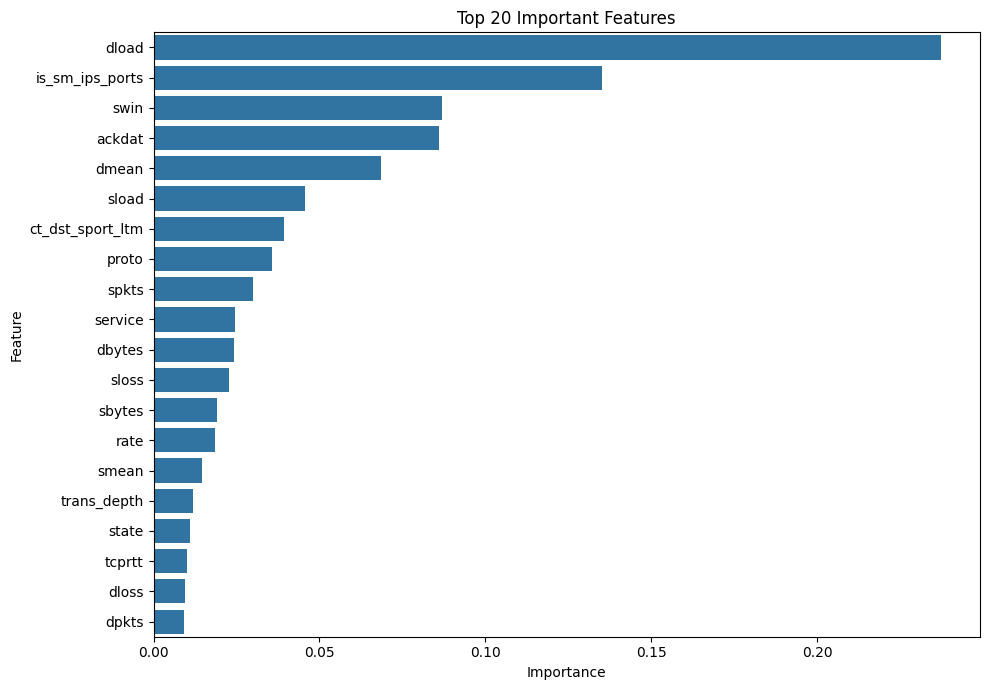

In [39]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
).head(20)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Important Features")
plt.tight_layout()
plt.show()

In [40]:
joblib.dump(
    model,
    "/content/unsw_nb15_xgboost_model.joblib"
)

joblib.dump(
    encoders,
    "/content/unsw_nb15_feature_encoders.joblib"
)

joblib.dump(
    list(X_train.columns),
    "/content/unsw_nb15_features.joblib"
)

print("Model files saved successfully! ✅")

Model files saved successfully! ✅


In [42]:
from google.colab import files

files.download("/content/unsw_nb15_xgboost_model.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [43]:
files.download("/content/unsw_nb15_feature_encoders.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [44]:
files.download("/content/unsw_nb15_features.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [45]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)

print(f"F1 Score: {f1:.4f}")
print(f"F1 Score (%): {f1 * 100:.2f}%")

F1 Score: 0.8921
F1 Score (%): 89.21%


In [46]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Normal", "Attack"]
))

              precision    recall  f1-score   support

      Normal       0.96      0.74      0.84     37000
      Attack       0.82      0.98      0.89     45332

    accuracy                           0.87     82332
   macro avg       0.89      0.86      0.86     82332
weighted avg       0.88      0.87      0.87     82332



In [47]:
print(f"Accuracy : {accuracy * 100:.2f}%")
print(f"F1 Score : {f1 * 100:.2f}%")
print(f"ROC-AUC  : {roc_auc:.4f}")


Accuracy : 87.01%
F1 Score : 89.21%
ROC-AUC  : 0.9810


In [74]:
import pandas as pd
import numpy as np
import joblib
model = joblib.load(
    "/content/model/unsw_nb15_multiclass_xgboost_model.joblib"
)
feature_encoders = joblib.load(
    "/content/model/unsw_nb15_multiclass_feature_encoders.joblib"
)
target_encoder = joblib.load(
    "/content/model/unsw_nb15_multiclass_target_encoder.joblib"
)
feature_names = joblib.load(
    "/content/model/unsw_nb15_multiclass_features.joblib"
)
print("Saved multiclass model loaded successfully!")
print("Number of classes:", len(target_encoder.classes_))
print("\nClasses:")
for i, name in enumerate(target_encoder.classes_):
    print(i, "=", name)

Saved multiclass model loaded successfully!
Number of classes: 10

Classes:
0 = Analysis
1 = Backdoor
2 = DoS
3 = Exploits
4 = Fuzzers
5 = Generic
6 = Normal
7 = Reconnaissance
8 = Shellcode
9 = Worms


In [75]:
test_df = pd.read_parquet(
    "/content/unsw_dataset/UNSW_NB15_testing-set.parquet"
)
print("Test dataset shape:", test_df.shape)
y_test_text = test_df["attack_cat"].astype(str).str.strip()
X_test = test_df.drop(
    columns=["id", "attack_cat", "label"],
    errors="ignore"
).copy()
categorical_columns = ["proto", "service", "state"]
for col in categorical_columns:
    if col in X_test.columns:
        encoder = feature_encoders[col]
        X_test[col] = X_test[col].astype(str)
        X_test[col] = X_test[col].map(
            lambda x: encoder.transform([x])[0]
            if x in encoder.classes_
            else -1
        )
X_test = X_test.replace([np.inf, -np.inf], np.nan)
X_test = X_test.fillna(0)
X_test = X_test.reindex(
    columns=feature_names,
    fill_value=0
)
y_test_encoded = target_encoder.transform(y_test_text)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test_encoded.shape)
print("Test data prepared successfully!")

Test dataset shape: (82332, 36)
X_test shape: (82332, 34)
y_test shape: (82332,)
Test data prepared successfully!


In [76]:
y_pred = model.predict(X_test)
y_pred = y_pred.astype(int)
print("Prediction completed!")
print("Number of predictions:", len(y_pred))
print("\nFirst 10 predicted class numbers:")
print(y_pred[:10])

Prediction completed!
Number of predictions: 82332

First 10 predicted class numbers:
[8 4 4 4 4 4 4 4 6 6]


In [77]:
y_prob = model.predict_proba(X_test)
print("Probability prediction completed!")
print("Probability shape:", y_prob.shape)
print("Number of classes:", len(target_encoder.classes_))
print("\nClass order:")
for i, class_name in enumerate(target_encoder.classes_):
    print(i, "=", class_name)

Probability prediction completed!
Probability shape: (82332, 10)
Number of classes: 10

Class order:
0 = Analysis
1 = Backdoor
2 = DoS
3 = Exploits
4 = Fuzzers
5 = Generic
6 = Normal
7 = Reconnaissance
8 = Shellcode
9 = Worms


In [79]:
normal_index = list(
    target_encoder.classes_
).index("Normal")
normal_probability = y_prob[:, normal_index]
attack_probability = 1 - normal_probability
risk_score = attack_probability * 100
print("Risk score generated successfully!")
print("\nFirst 10 predictions:")
for i in range(10):
    print(
        f"{i+1}. "
        f"Normal Probability: {normal_probability[i] * 100:.2f}% | "
        f"Attack Probability: {attack_probability[i] * 100:.2f}% | "
        f"Risk Score: {risk_score[i]:.2f}"
    )

Risk score generated successfully!

First 10 predictions:
1. Normal Probability: 6.69% | Attack Probability: 93.31% | Risk Score: 93.31
2. Normal Probability: 13.01% | Attack Probability: 86.99% | Risk Score: 86.99
3. Normal Probability: 18.32% | Attack Probability: 81.68% | Risk Score: 81.68
4. Normal Probability: 43.17% | Attack Probability: 56.83% | Risk Score: 56.83
5. Normal Probability: 34.73% | Attack Probability: 65.27% | Risk Score: 65.27
6. Normal Probability: 25.46% | Attack Probability: 74.54% | Risk Score: 74.54
7. Normal Probability: 38.84% | Attack Probability: 61.16% | Risk Score: 61.16
8. Normal Probability: 17.81% | Attack Probability: 82.19% | Risk Score: 82.19
9. Normal Probability: 99.99% | Attack Probability: 0.01% | Risk Score: 0.01
10. Normal Probability: 99.99% | Attack Probability: 0.01% | Risk Score: 0.01


In [80]:
def get_risk_level(score):
    if score < 30:
        return "LOW"
    elif score < 70:
        return "MEDIUM"
    else:
        return "HIGH"
risk_levels = [
    get_risk_level(score)
    for score in risk_score
]
print("Risk levels generated successfully!")
print("\nRisk Level Distribution:")
print(
    pd.Series(risk_levels).value_counts()
)

Risk levels generated successfully!

Risk Level Distribution:
HIGH      45882
LOW       23025
MEDIUM    13425
Name: count, dtype: int64


In [81]:
predicted_attack = target_encoder.inverse_transform(
    y_pred.astype(int)
)
print("Predicted attack categories generated!")
print("\nFirst 20 predictions:")
for i in range(20):
    print(
        f"{i+1}. "
        f"Attack: {predicted_attack[i]} | "
        f"Risk: {risk_score[i]:.2f} | "
        f"Level: {risk_levels[i]}"
    )

Predicted attack categories generated!

First 20 predictions:
1. Attack: Shellcode | Risk: 93.31 | Level: HIGH
2. Attack: Fuzzers | Risk: 86.99 | Level: HIGH
3. Attack: Fuzzers | Risk: 81.68 | Level: HIGH
4. Attack: Fuzzers | Risk: 56.83 | Level: MEDIUM
5. Attack: Fuzzers | Risk: 65.27 | Level: MEDIUM
6. Attack: Fuzzers | Risk: 74.54 | Level: HIGH
7. Attack: Fuzzers | Risk: 61.16 | Level: MEDIUM
8. Attack: Fuzzers | Risk: 82.19 | Level: HIGH
9. Attack: Normal | Risk: 0.01 | Level: LOW
10. Attack: Normal | Risk: 0.01 | Level: LOW
11. Attack: Normal | Risk: 0.01 | Level: LOW
12. Attack: Normal | Risk: 0.01 | Level: LOW
13. Attack: Fuzzers | Risk: 89.55 | Level: HIGH
14. Attack: Fuzzers | Risk: 86.25 | Level: HIGH
15. Attack: Fuzzers | Risk: 80.93 | Level: HIGH
16. Attack: Fuzzers | Risk: 88.31 | Level: HIGH
17. Attack: Shellcode | Risk: 93.63 | Level: HIGH
18. Attack: Fuzzers | Risk: 80.99 | Level: HIGH
19. Attack: Fuzzers | Risk: 87.48 | Level: HIGH
20. Attack: Fuzzers | Risk: 87.15 | L

In [82]:
actual_attack = target_encoder.inverse_transform(
    y_test_encoded
)
results = pd.DataFrame({
    "Actual_Attack": actual_attack,
    "Predicted_Attack": predicted_attack,
    "Normal_Probability": normal_probability,
    "Attack_Probability": attack_probability,
    "Risk_Score": risk_score,
    "Risk_Level": risk_levels
})
print("Detection report created!")
print("\nFirst 10 rows:")
print(results.head(10))

Detection report created!

First 10 rows:
  Actual_Attack Predicted_Attack  Normal_Probability  Attack_Probability  \
0        Normal        Shellcode            0.066873            0.933127   
1        Normal          Fuzzers            0.130091            0.869909   
2        Normal          Fuzzers            0.183214            0.816786   
3        Normal          Fuzzers            0.431668            0.568332   
4        Normal          Fuzzers            0.347277            0.652723   
5        Normal          Fuzzers            0.254580            0.745420   
6        Normal          Fuzzers            0.388362            0.611638   
7        Normal          Fuzzers            0.178136            0.821864   
8        Normal           Normal            0.999880            0.000120   
9        Normal           Normal            0.999880            0.000120   

   Risk_Score Risk_Level  
0   93.312691       HIGH  
1   86.990921       HIGH  
2   81.678635       HIGH  
3   56.833244

In [83]:
report_path = (
    "/content/model/"
    "netshield_milestone2_detection_report.csv"
)
results.to_csv(
    report_path,
    index=False
)
print("Detection report saved successfully!")
print(report_path)

Detection report saved successfully!
/content/model/netshield_milestone2_detection_report.csv


In [84]:
from google.colab import files
files.download(
    "/content/model/netshield_milestone2_detection_report.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [85]:
print("=" * 60)
print("NETSHIELD RISK SCORE ANALYSIS")
print("=" * 60)
print(
    f"Minimum Risk Score : {risk_score.min():.2f}"
)
print(
    f"Maximum Risk Score : {risk_score.max():.2f}"
)
print(
    f"Average Risk Score : {risk_score.mean():.2f}"
)
print(
    f"Median Risk Score  : {np.median(risk_score):.2f}"
)
print("\nRisk Levels:")
print(
    pd.Series(risk_levels).value_counts()
)

NETSHIELD RISK SCORE ANALYSIS
Minimum Risk Score : 0.00
Maximum Risk Score : 100.00
Average Risk Score : 63.03
Median Risk Score  : 86.98

Risk Levels:
HIGH      45882
LOW       23025
MEDIUM    13425
Name: count, dtype: int64


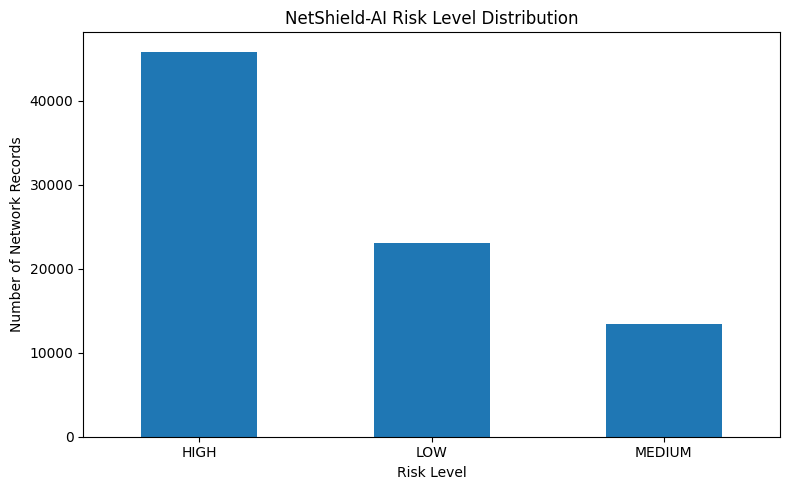

In [86]:
risk_counts = pd.Series(
    risk_levels
).value_counts()
plt.figure(figsize=(8, 5))
risk_counts.plot(
    kind="bar"
)
plt.title(
    "NetShield-AI Risk Level Distribution"
)
plt.xlabel("Risk Level")
plt.ylabel(
    "Number of Network Records"
)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

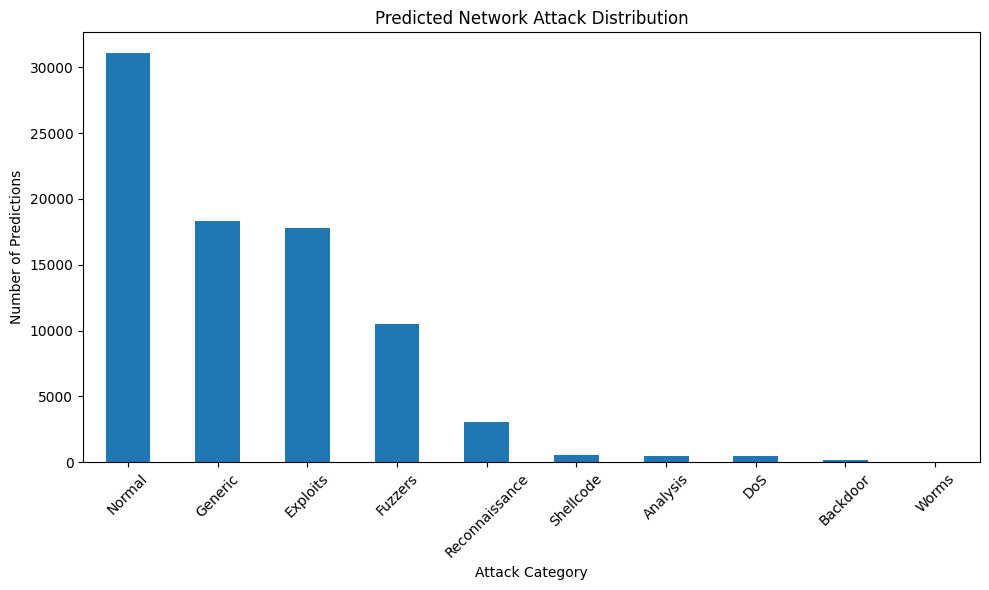

In [87]:
attack_counts = pd.Series(
    predicted_attack
).value_counts()
plt.figure(figsize=(10, 6))
attack_counts.plot(
    kind="bar"
)
plt.title(
    "Predicted Network Attack Distribution"
)
plt.xlabel("Attack Category")
plt.ylabel(
    "Number of Predictions"
)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [88]:
high_risk = results[
    results["Risk_Level"] == "HIGH"
]
print("=" * 60)
print("HIGH RISK THREAT REPORT")
print("=" * 60)
print(
    "Total high-risk records:",
    len(high_risk)
)
print("\nHigh-risk attack categories:")
print(
    high_risk[
        "Predicted_Attack"
    ].value_counts()
)

HIGH RISK THREAT REPORT
Total high-risk records: 45882

High-risk attack categories:
Predicted_Attack
Generic           18353
Exploits          17469
Fuzzers            5587
Reconnaissance     3013
Shellcode           558
DoS                 416
Analysis            269
Backdoor            179
Normal               21
Worms                17
Name: count, dtype: int64


In [89]:
high_risk.to_csv(
    "/content/model/netshield_high_risk_report.csv",
    index=False
)
print(
    "High-risk report saved successfully!"
)

High-risk report saved successfully!


In [90]:
actual_is_attack = (
    actual_attack != "Normal"
)
predicted_is_attack = (
    predicted_attack != "Normal"
)
detection_rate = (
    (
        actual_is_attack
        & predicted_is_attack
    ).sum()
    / actual_is_attack.sum()
)
print(
    f"Attack Detection Rate: "
    f"{detection_rate * 100:.2f}%"
)

Attack Detection Rate: 96.27%


In [92]:
from sklearn.metrics import (
    accuracy_score,
    f1_score
)
final_accuracy = accuracy_score(
    y_test_encoded,
    y_pred
)
weighted_f1 = f1_score(
    y_test_encoded,
    y_pred,
    average="weighted"
)
print("=" * 70)
print("=" * 70)
print(
    "\nDataset              : UNSW-NB15"
)

print(
    "Model                : XGBoost"
)
print(
    "Classification       : Multi-Class"
)
print(
    "Number of Classes    :",
    len(target_encoder.classes_)
)
print(
    f"\nAccuracy             : "
    f"{final_accuracy * 100:.2f}%"
)
print(
    f"Weighted F1 Score    : "
    f"{weighted_f1 * 100:.2f}%"
)
print(
    f"Attack Detection Rate: "
    f"{detection_rate * 100:.2f}%"
)
print(
    f"\nMinimum Risk Score   : "
    f"{risk_score.min():.2f}"
)
print(
    f"Maximum Risk Score   : "
    f"{risk_score.max():.2f}"
)
print(
    f"Average Risk Score   : "
    f"{risk_score.mean():.2f}"
)
print("\nRisk Distribution:")
print(
    pd.Series(risk_levels).value_counts()
)
print("\nAttack Categories:")
for category in target_encoder.classes_:
    print("-", category)



Dataset              : UNSW-NB15
Model                : XGBoost
Classification       : Multi-Class
Number of Classes    : 10

Accuracy             : 78.73%
Weighted F1 Score    : 78.66%
Attack Detection Rate: 96.27%

Minimum Risk Score   : 0.00
Maximum Risk Score   : 100.00
Average Risk Score   : 63.03

Risk Distribution:
HIGH      45882
LOW       23025
MEDIUM    13425
Name: count, dtype: int64

Attack Categories:
- Analysis
- Backdoor
- DoS
- Exploits
- Fuzzers
- Generic
- Normal
- Reconnaissance
- Shellcode
- Worms


In [48]:
import os

for f in os.listdir("/content"):
    if f.endswith(".joblib"):
        print(f)

unsw_nb15_features.joblib
unsw_nb15_feature_encoders.joblib
unsw_nb15_xgboost_model.joblib


In [49]:
model.save_model("/content/unsw_nb15_xgboost_model.json")

In [50]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    random_state=42
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [51]:
!pip install -q xgboost joblib pyarrow

In [52]:
import pandas as pd
import numpy as np
import os
import joblib

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier
import matplotlib.pyplot as plt

In [53]:
train_path = "/content/unsw_dataset/UNSW_NB15_training-set.parquet"
test_path = "/content/unsw_dataset/UNSW_NB15_testing-set.parquet"

train_df = pd.read_parquet(train_path)
test_df = pd.read_parquet(test_path)

print("Training shape:", train_df.shape)
print("Testing shape :", test_df.shape)

Training shape: (175341, 36)
Testing shape : (82332, 36)


In [54]:
print("Training columns:")
print(train_df.columns.tolist())

print("\nAttack categories:")
print(train_df["attack_cat"].value_counts())

Training columns:
['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'is_sm_ips_ports', 'attack_cat', 'label']

Attack categories:
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64


In [55]:
target_col = "attack_cat"

y_train = train_df[target_col].astype(str)
y_test = test_df[target_col].astype(str)

print("Classes:")
print(sorted(y_train.unique()))

Classes:
['Analysis', 'Backdoor', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Normal', 'Reconnaissance', 'Shellcode', 'Worms']


In [56]:
drop_columns = ["id", "attack_cat", "label"]

X_train = train_df.drop(columns=drop_columns, errors="ignore")
X_test = test_df.drop(columns=drop_columns, errors="ignore")

print("Features before encoding:", X_train.shape[1])
print("Feature names:")
print(X_train.columns.tolist())

Features before encoding: 34
Feature names:
['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'is_sm_ips_ports']


In [57]:
encoders = {}

categorical_columns = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

for col in categorical_columns:

    encoder = LabelEncoder()

    # Combine train + test categories so unseen test categories
    # don't cause encoding problems
    combined = pd.concat([
        X_train[col].astype(str),
        X_test[col].astype(str)
    ])

    encoder.fit(combined)

    X_train[col] = encoder.transform(X_train[col].astype(str))
    X_test[col] = encoder.transform(X_test[col].astype(str))

    encoders[col] = encoder

Categorical columns:
['proto', 'service', 'state']


In [58]:
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

print("Missing values in training:", X_train.isna().sum().sum())
print("Missing values in testing :", X_test.isna().sum().sum())

Missing values in training: 0
Missing values in testing : 0


In [59]:
target_encoder = LabelEncoder()

y_train_encoded = target_encoder.fit_transform(y_train)
y_test_encoded = target_encoder.transform(y_test)

print("Class mapping:")

for number, category in enumerate(target_encoder.classes_):
    print(number, "=", category)

Class mapping:
0 = Analysis
1 = Backdoor
2 = DoS
3 = Exploits
4 = Fuzzers
5 = Generic
6 = Normal
7 = Reconnaissance
8 = Shellcode
9 = Worms


In [60]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train_encoded.shape)
print("y_test :", y_test_encoded.shape)

print("Number of classes:", len(target_encoder.classes_))

X_train: (175341, 34)
X_test : (82332, 34)
y_train: (175341,)
y_test : (82332,)
Number of classes: 10


In [62]:
num_classes = len(target_encoder.classes_)

model = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,

    objective="multi:softprob",
    num_class=num_classes,

    eval_metric="mlogloss",

    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

print("Training XGBoost...")

model.fit(
    X_train,
    y_train_encoded
)

print("Training completed!")

Training XGBoost...
Training completed!


In [63]:
y_pred = model.predict(X_test)

y_pred = y_pred.astype(int)

In [64]:
accuracy = accuracy_score(
    y_test_encoded,
    y_pred
)

print(f"Multi-Class Accuracy: {accuracy * 100:.2f}%")

Multi-Class Accuracy: 78.73%


In [65]:
print("\nClassification Report:\n")

print(
    classification_report(
        y_test_encoded,
        y_pred,
        target_names=target_encoder.classes_,
        zero_division=0
    )
)


Classification Report:

                precision    recall  f1-score   support

      Analysis       0.01      0.01      0.01       677
      Backdoor       0.20      0.06      0.09       583
           DoS       0.67      0.07      0.13      4089
      Exploits       0.58      0.92      0.71     11132
       Fuzzers       0.33      0.57      0.42      6062
       Generic       1.00      0.97      0.98     18871
        Normal       0.95      0.80      0.86     37000
Reconnaissance       0.93      0.81      0.87      3496
     Shellcode       0.43      0.65      0.52       378
         Worms       0.53      0.20      0.30        44

      accuracy                           0.79     82332
     macro avg       0.56      0.51      0.49     82332
  weighted avg       0.83      0.79      0.79     82332



<Figure size 1200x1000 with 0 Axes>

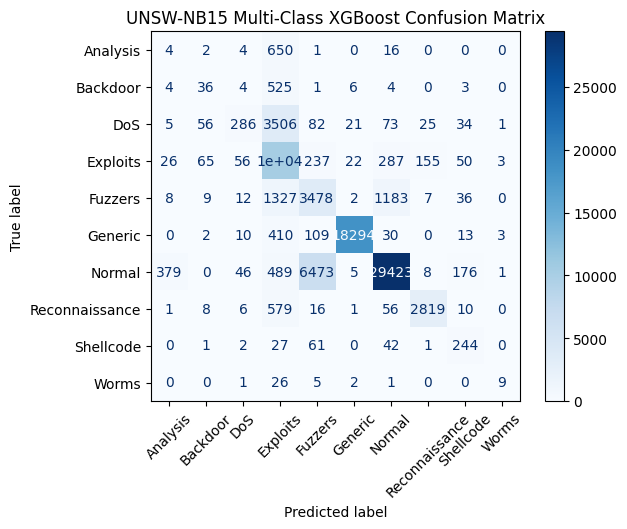

In [66]:
cm = confusion_matrix(
    y_test_encoded,
    y_pred
)

plt.figure(figsize=(12, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_encoder.classes_
)

disp.plot(
    xticks_rotation=45,
    cmap="Blues"
)

plt.title("UNSW-NB15 Multi-Class XGBoost Confusion Matrix")
plt.show()


In [67]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(20))

             Feature  Importance
29  ct_dst_sport_ltm    0.257062
33   is_sm_ips_ports    0.138873
17              swin    0.065674
10             dload    0.064553
2            service    0.056829
6             sbytes    0.035357
28  ct_src_dport_ltm    0.033527
23            ackdat    0.030951
25             dmean    0.029479
1              proto    0.029098
7             dbytes    0.028772
24             smean    0.026614
9              sload    0.019236
26       trans_depth    0.017564
32  ct_flw_http_mthd    0.014954
11             sloss    0.014860
12             dloss    0.014711
3              state    0.014461
22            synack    0.014206
21            tcprtt    0.013872


In [68]:
os.makedirs("/content/model", exist_ok=True)

In [69]:
model_path = "/content/model/unsw_nb15_multiclass_xgboost_model.joblib"

joblib.dump(
    model,
    model_path
)

print("Model saved:", model_path)

Model saved: /content/model/unsw_nb15_multiclass_xgboost_model.joblib


In [71]:
features_path = "/content/model/unsw_nb15_multiclass_features.joblib"

joblib.dump(
    X_train.columns.tolist(),
    features_path
)

print("Features saved:", features_path)


Features saved: /content/model/unsw_nb15_multiclass_features.joblib


In [70]:
encoders_path = "/content/model/unsw_nb15_multiclass_feature_encoders.joblib"

joblib.dump(
    encoders,
    encoders_path
)

print("Feature encoders saved:", encoders_path)

Feature encoders saved: /content/model/unsw_nb15_multiclass_feature_encoders.joblib


In [72]:
target_encoder_path = "/content/model/unsw_nb15_multiclass_target_encoder.joblib"

joblib.dump(
    target_encoder,
    target_encoder_path
)

print("Target encoder saved:", target_encoder_path)

Target encoder saved: /content/model/unsw_nb15_multiclass_target_encoder.joblib


In [73]:
from google.colab import files

files.download(
    "/content/model/unsw_nb15_multiclass_xgboost_model.joblib"
)

files.download(
    "/content/model/unsw_nb15_multiclass_features.joblib"
)

files.download(
    "/content/model/unsw_nb15_multiclass_feature_encoders.joblib"
)

files.download(
    "/content/model/unsw_nb15_multiclass_target_encoder.joblib"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>